# Data model

This notebook introduces the core `BaseData` data model using a small synthetic
thermogravimetric-analysis (TGA) dataset.

The example covers:

- declaring a schema with `Column`
- constructing a `BaseData` subclass
- adding derived columns
- working with units and normalization
- filtering and downsampling
- saving and loading data
- making a quick plot

In [1]:
import numpy as np
import polars as pl

from exptoolkit.data import BaseData, Column, Role

## Create synthetic data

The dataset is generated in the notebook so that the example is self-contained.
It roughly resembles a TGA measurement with two mass-loss regions.

In [2]:
time = np.arange(0.0, 1801.0, 10.0)
temperature = 25.0 + 0.25 * time

loss_1 = 1.2 / (1.0 + np.exp(-(temperature - 220.0) / 18.0))
loss_2 = 3.4 / (1.0 + np.exp(-(temperature - 500.0) / 35.0))
weight = 20.0 - loss_1 - loss_2

df = pl.DataFrame(
    {
        "time": time,
        "temperature": temperature,
        "weight": weight,
    }
)

df.head()

time,temperature,weight
f64,f64,f64
0.0,25.0,19.999972
10.0,27.5,19.999968
20.0,30.0,19.999964
30.0,32.5,19.999959
40.0,35.0,19.999953


## Define the schema

A `BaseData` subclass declares its columns with `Column`.

`role` describes how a quantity responds to normalization:

- `Role.INTENSIVE`: independent of sample amount
- `Role.EXTENSIVE`: proportional to sample amount
- `Role.INVERSE_EXTENSIVE`: inversely proportional to sample amount

In [3]:
class TGA(BaseData):
    time = Column(pl.Float64, base_unit="s", role=Role.INTENSIVE)
    temperature = Column(pl.Float64, base_unit="degC", role=Role.INTENSIVE)
    weight = Column(pl.Float64, base_unit="mg", role=Role.EXTENSIVE)
    dtg = Column(pl.Float64, base_unit="mg/s", role=Role.EXTENSIVE)


TGA.schema

mappingproxy({'time': ColumnSpec(role=<Role.INTENSIVE: 0>, dtype=Float64, base_unit='s'),
              'temperature': ColumnSpec(role=<Role.INTENSIVE: 0>, dtype=Float64, base_unit='degC'),
              'weight': ColumnSpec(role=<Role.EXTENSIVE: 1>, dtype=Float64, base_unit='mg'),
              'dtg': ColumnSpec(role=<Role.EXTENSIVE: 1>, dtype=Float64, base_unit='mg/s')})

## Create a data object

Columns required by the schema but absent from the input table are inserted as
null columns. Metadata is free-form but JSON-compatible.

In [4]:
data = TGA(
    df,
    metadata={
        "sample": "synthetic TGA example",
        "instrument": "simulated",
    },
)

data.table.head()

time,temperature,weight,dtg
f64,f64,f64,f64
0.0,25.0,19.999972,null
10.0,27.5,19.999968,null
20.0,30.0,19.999964,null
30.0,32.5,19.999959,null
40.0,35.0,19.999953,null


In [5]:
data.metadata

JSONDict({'sample': 'synthetic TGA example', 'instrument': 'simulated'})

## Add a derived column

Schema columns are descriptors, so derived data can be assigned directly while
the declared dtype is preserved.

In [6]:
data.dtg = np.gradient(data.weight.to_numpy(), data.time.to_numpy())

data.table.select(
    "time",
    "temperature",
    "weight",
    "dtg",
).head()

time,temperature,weight,dtg
f64,f64,f64,f64
0.0,25.0,19.999972,-3.8490e-7
10.0,27.5,19.999968,-4.1236e-7
20.0,30.0,19.999964,-4.7130e-7
30.0,32.5,19.999959,-5.3884e-7
40.0,35.0,19.999953,-6.1624e-7


## Units

The stored values use each column's base unit. `col_to_unit()` converts a column
for use without changing the stored table.

In [7]:
time_minutes = data.col_to_unit("time", "min")

pl.DataFrame(
    {
        "time_s": data.time.head(),
        "time_min": time_minutes.head(),
    }
)

time_s,time_min
f64,f64
0.0,0.0
10.0,0.166667
20.0,0.333333
30.0,0.5
40.0,0.666667
50.0,0.833333
60.0,1.0
70.0,1.166667
80.0,1.333333


## Normalize extensive quantities

Here the data is normalized by the initial sample mass. Intensive columns such
as time and temperature are unchanged, while extensive columns such as weight
and DTG are divided by the normalization amount.

In [8]:
normalized = data.normalize(data.weight[0], "mg")

print("weight unit:", normalized.get_unit("weight"))
print("DTG unit:", normalized.get_unit("dtg"))

normalized.df_to_units(weight="%").select(
    "temperature",
    "weight",
    "dtg",
).head()

weight unit: 
DTG unit: 1/s


temperature,weight,dtg
f64,f64,f64
25.0,100.0,-1.9245e-8
27.5,99.999981,-2.0618e-8
30.0,99.999959,-2.3565e-8
32.5,99.999934,-2.6942e-8
35.0,99.999905,-3.0812e-8


## Filter and downsample

Operations that return a new table preserve the data model and metadata.

In [9]:
window = normalized.filter(
    TGA.temperature.expr.is_between(150.0, 650.0)
)

reduced = window.downsample(5)

print(type(reduced).__name__)
print(reduced.table.shape)
reduced.table.head()

TGA
(27, 4)


time,temperature,weight,dtg
f64,f64,f64,f64
500.0,150.0,0.99879,-0.000016
550.0,162.5,0.997628,-0.000032
600.0,175.0,0.995434,-0.000059
650.0,187.5,0.991508,-0.000101
700.0,200.0,0.985109,-0.000155


## Save and load

`BaseData.save()` stores the table as Parquet together with a JSON manifest in a
ZIP container. The example uses a temporary directory so that running the
notebook does not leave generated files in the repository.

In [10]:
from tempfile import TemporaryDirectory
from pathlib import Path

with TemporaryDirectory() as tmpdir:
    path = Path(tmpdir) / "tga.zip"
    normalized.save(path)
    restored = TGA.load(path)

print(restored.norm)
print(restored.metadata)
restored.table.head()

NormPolicy(amount=19.9999719836724, unit='mg')
JSONDict({'sample': 'synthetic TGA example', 'instrument': 'simulated'})


time,temperature,weight,dtg
f64,f64,f64,f64
0.0,25.0,1.0,-1.9245e-8
10.0,27.5,1.0,-2.0618e-8
20.0,30.0,1.0,-2.3565e-8
30.0,32.5,0.999999,-2.6942e-8
40.0,35.0,0.999999,-3.0812e-8


## Quick plot

Plotting is intentionally only touched on here. See `plotting.ipynb` for the
backend-independent plotting layer.

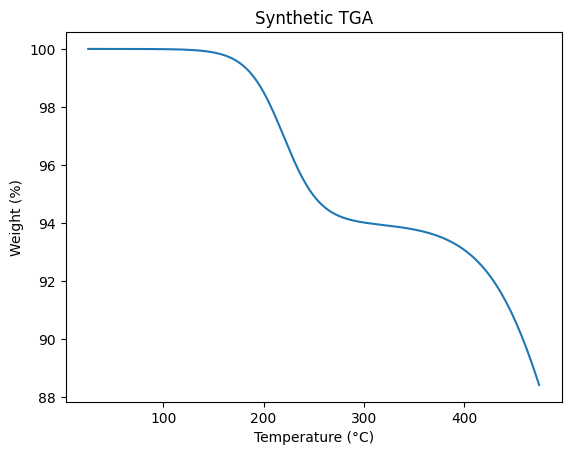

In [11]:
import matplotlib.pyplot as plt

from exptoolkit.plotter import XyPlotter

fig, ax = plt.subplots()
XyPlotter("temperature", "weight", yunit="%").plot(normalized, ax)
ax.set_title("Synthetic TGA")
plt.show()